In [ ]:
# import shutil
# shutil.rmtree("/content/sample_data")

In [1]:
import zipfile
file = zipfile.ZipFile("/content/skin.yolov11.zip")
file.extractall()

In [9]:
!pip install ultralytics

In [10]:
import os
from ultralytics import YOLO

model = YOLO('yolo11n.pt')

In [12]:
import os

yaml_content = """
train: /content/train
val: /content/valid
test: /content/test

nc: 1
names: ['acne']
"""

# Force write file to the absolute path
target_path = '/content/dataset.yaml'
with open(target_path, 'w') as f:
    f.write(yaml_content.strip())

# Hard check to verify existence before YOLO triggers
if os.path.exists(target_path):
    print(f"✅ Success! 'dataset.yaml' confirmed online at: {target_path}")
    print("--------------------------------------------------")
    with open(target_path, 'r') as f:
        print(f.read())
else:
    print("❌ Error: Path writing failed. Check Colab storage permissions.")


✅ Success! 'dataset.yaml' confirmed online at: /content/dataset.yaml
--------------------------------------------------
train: /content/train
val: /content/valid
test: /content/test

nc: 1
names: ['acne']


In [13]:
results = model.train(
    data='/content/dataset.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    plots=True
)

Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, 

In [14]:
print("Exporting model weights...")
model.export(format='onnx', imgsz=640)

Exporting model weights...
Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from '/content/runs/detect/train-3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 392ms
Prepared 4 packages in 2.06s
Installed 4 packages in 529ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.28.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0

'/content/runs/detect/train-3/weights/best.onnx'

In [20]:
new_model = YOLO("/content/runs/detect/train-3/weights/best.pt")

In [21]:
result = new_model("/content/test/images/Leonardo_Kino_XL_A_realistic_highresolution_portrait_of_a_sing_2-2-_jpg.rf.lLlZ0pp0ppVvezxAQIQW.jpg", save=True)


image 1/1 /content/test/images/Leonardo_Kino_XL_A_realistic_highresolution_portrait_of_a_sing_2-2-_jpg.rf.lLlZ0pp0ppVvezxAQIQW.jpg: 640x640 3 acnes, 11.6ms
Speed: 5.0ms preprocess, 11.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2


In [22]:
test_metrics = new_model.val(data="/content/data.yaml", split="test")

print(f"Test mAP50: {test_metrics.box.map50:.4f}")
print(f"Test Precision: {test_metrics.box.mp:.4f}")
print(f"Test Recall: {test_metrics.box.mr:.4f}")


Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1782.9±292.7 MB/s, size: 73.9 KB)
val: Scanning /content/test/labels.cache... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 1.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.6it/s 0.2s
                   all          8         86      0.527      0.453      0.368      0.125
Speed: 0.4ms preprocess, 7.1ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/val-2
Test mAP50: 0.3677
Test Precision: 0.5267
Test Recall: 0.4535


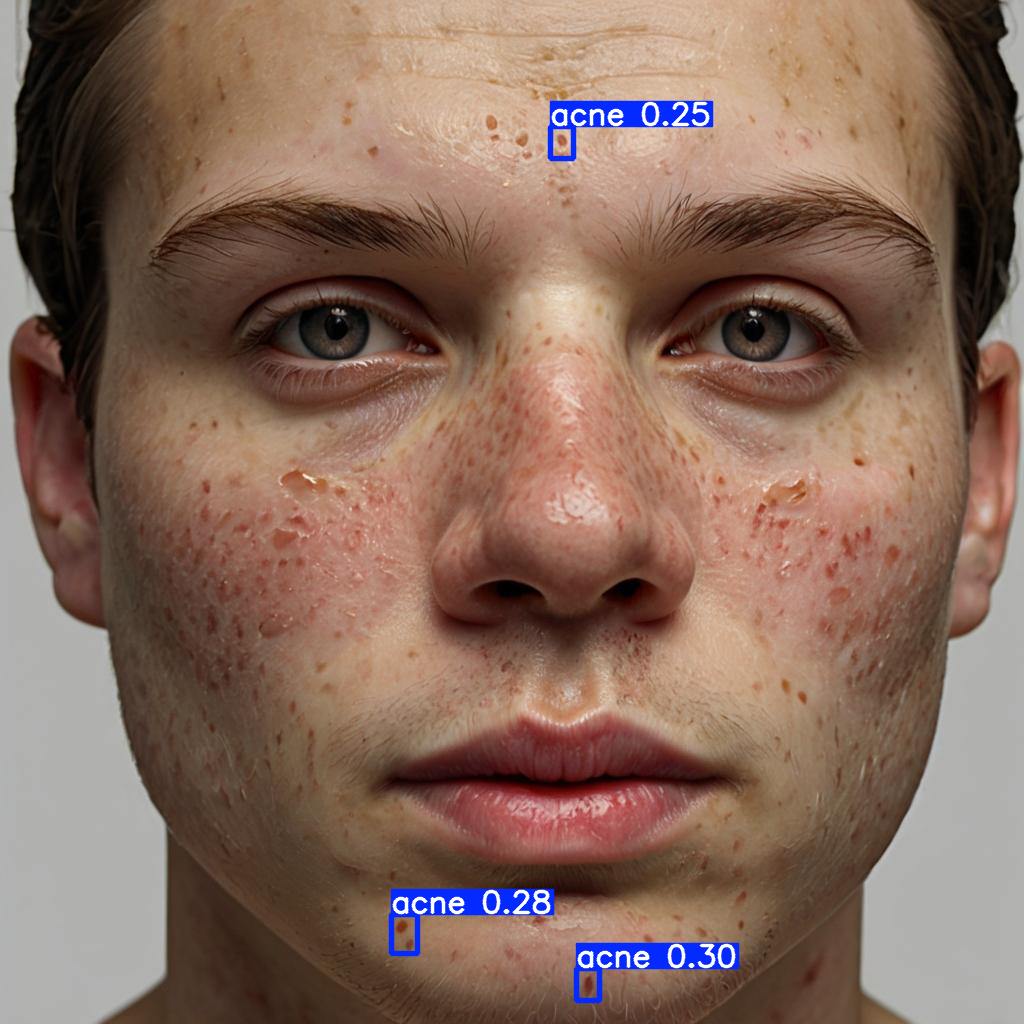

In [23]:
result[0].show()

In [ ]:
for r in results:
    im_bgr = r.plot()
    cv2_imshow(im_bgr)

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

In [ ]:
def gr_function(image):
  result = new_model("/content/runs/detect/train-3/weights/best.pt")
  image = result[0].plot()
  return image


In [ ]:
app = gr.Interface(
    fn=gr_function,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Image(type="numpy")
)

In [ ]:
app.launch(share=True)